# End-to-End Telco Customer Churn Prediction Pipeline
This notebook builds an end-to-end Machine Learning pipeline using Scikit-Learn's `Pipeline` and `ColumnTransformer` APIs. It implements data cleaning, imputation, scaling, categorical encoding, model training, hyperparameter tuning via `GridSearchCV`, model evaluation, and saving the final model pipeline using `joblib`.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Add src to system path to import modules
import sys
sys.path.append("../src")
from data_ingestion import download_data, load_data
from pipeline import get_preprocessing_pipeline

## 1. Data Ingestion
We download the dataset programmatically if it doesn't exist, and load it into a pandas DataFrame.

In [2]:
DATA_PATH = "../data/Telco-Customer-Churn.csv"
if not os.path.exists(DATA_PATH):
    download_data(dest_path=DATA_PATH)
df = load_data(DATA_PATH)
df.head()

Dataset loaded. Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Exploratory Data Analysis (EDA) & Visualization
Let's understand the dataset columns, types, check for missing values, and analyze the distribution of our target variable `Churn`.

In [3]:
print("Missing values in raw dataset:")
print(df.isnull().sum())
print("\nData types of columns:")
print(df.dtypes)

Missing values in raw dataset:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types of columns:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling      

### Cleaning 'TotalCharges'
Notice that `TotalCharges` is of type `object` (string) instead of float. This is because there are some blank spaces in the column. Let's find those rows.

In [4]:
empty_charges = df[df["TotalCharges"].str.strip() == ""]
print(f"Number of rows with empty TotalCharges: {len(empty_charges)}")
empty_charges[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Number of rows with empty TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


These rows correspond to customers with `tenure = 0` (new customers who haven't been billed yet). Our custom preprocessor pipeline will handle these by converting blank spaces to `NaN` and imputing them with the median `TotalCharges`.

### Target Distribution
Let's check if the dataset is balanced by plotting the distribution of `Churn`.

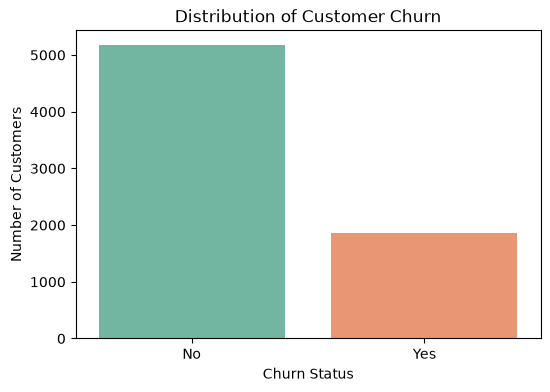

Churn Rate: Yes = 26.54%, No = 73.46%


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False)
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print(f"Churn Rate: Yes = {churn_pct['Yes']:.2f}%, No = {churn_pct['No']:.2f}%")

### Visualizing Numerical Features
Let's see how `tenure` and `MonthlyCharges` relate to `Churn`.

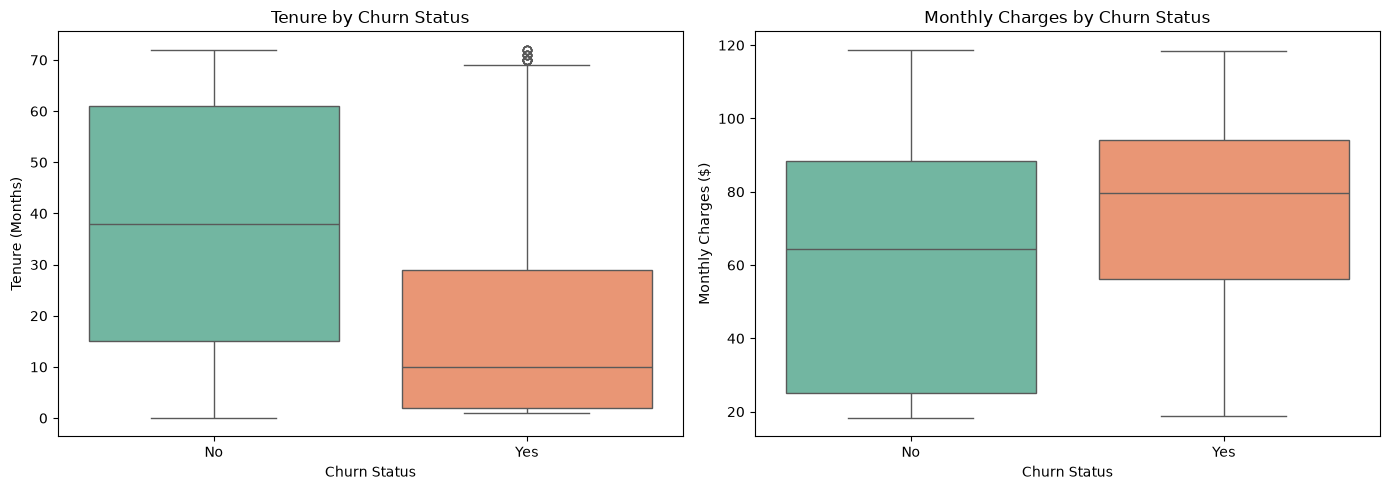

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0], hue="Churn", palette="Set2", legend=False)
axes[0].set_title("Tenure by Churn Status")
axes[0].set_xlabel("Churn Status")
axes[0].set_ylabel("Tenure (Months)")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1], hue="Churn", palette="Set2", legend=False)
axes[1].set_title("Monthly Charges by Churn Status")
axes[1].set_xlabel("Churn Status")
axes[1].set_ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()

- **Tenure:** Churned customers have significantly shorter tenure (median ~10 months) compared to retained customers (median ~38 months).
- **Monthly Charges:** Churned customers generally pay higher monthly charges (median ~$80) compared to retained customers (median ~$65).

### Visualizing Categorical Features
Let's look at how contract type and internet service type impact customer churn.

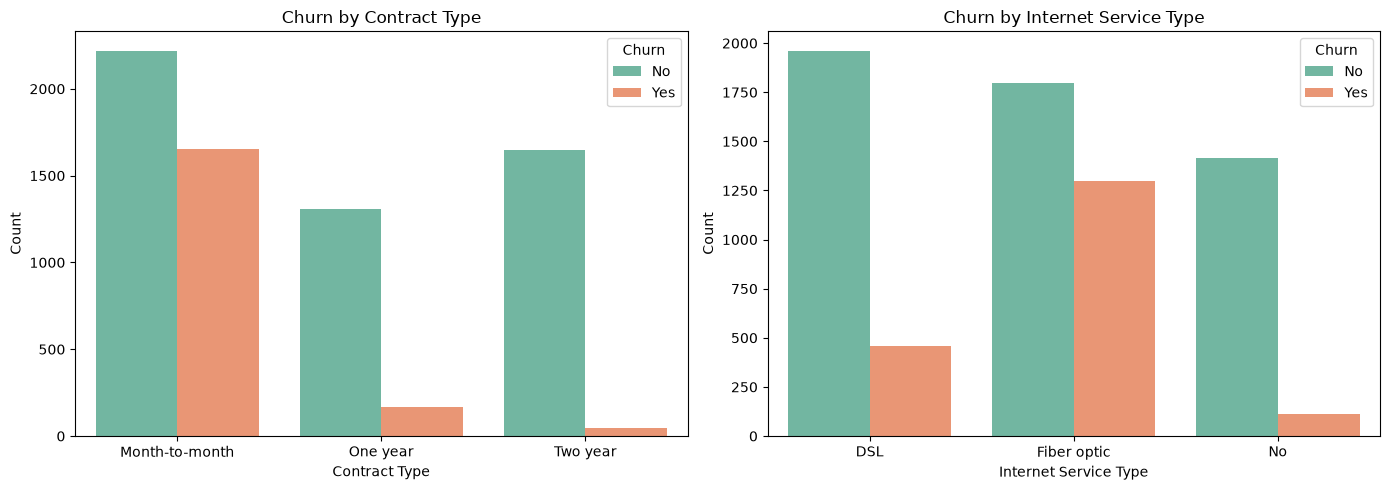

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0], palette="Set2")
axes[0].set_title("Churn by Contract Type")
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Count")

sns.countplot(data=df, x="InternetService", hue="Churn", ax=axes[1], palette="Set2")
axes[1].set_title("Churn by Internet Service Type")
axes[1].set_xlabel("Internet Service Type")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

- **Contract:** Customers on a month-to-month contract churn at a vastly higher rate than those on longer-term contracts.
- **Internet Service:** Fiber optic subscribers experience much higher churn than DSL or non-internet users.

---

## 3. Data Splitting and Pipeline Preprocessing
We encode our target variable `Churn` to binary labels (1 for Yes, 0 for No). We then split the data into training (80%) and testing (20%) sets. Preprocessing pipelines are defined and fitted only on the training set to prevent data leakage.

In [8]:
from sklearn.model_selection import train_test_split

df["Churn_encoded"] = df["Churn"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["customerID", "Churn", "Churn_encoded"])
y = df["Churn_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Define preprocessor
preprocessor = get_preprocessing_pipeline()

# Validate that preprocessing works
X_train_processed = preprocessor.fit_transform(X_train)
print(f"Processed training features shape: {X_train_processed.shape}")

X_train shape: (5634, 19)
X_test shape: (1409, 19)
Processed training features shape: (5634, 46)


---

## 4. Hyperparameter Tuning with GridSearchCV
We define Scikit-Learn pipelines combining our preprocessor and classifiers. We then run `GridSearchCV` with 5-fold cross-validation to find the optimal hyperparameters for:
1. **Logistic Regression**
2. **Random Forest**

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Build pipelines
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Param grids
lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0],
    "classifier__solver": ["lbfgs", "saga"],
    "classifier__penalty": ["l2"]
}

rf_param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5, 10]
}

# GridSearchCV
lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=5, scoring="f1", n_jobs=-1)
print("Running GridSearch for Logistic Regression...")
lr_grid.fit(X_train, y_train)
print(f"LR Best Params: {lr_grid.best_params_}")
print(f"LR Best CV F1 Score: {lr_grid.best_score_:.4f}")

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring="f1", n_jobs=-1)
print("\nRunning GridSearch for Random Forest...")
rf_grid.fit(X_train, y_train)
print(f"RF Best Params: {rf_grid.best_params_}")
print(f"RF Best CV F1 Score: {rf_grid.best_score_:.4f}")

Running GridSearch for Logistic Regression...


D:\DevelopersHub-Internship\PART 2\TASK2_END-TO-END ML PIPELINE WITH SCIKIT-LEARN PIPELINE API\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


LR Best Params: {'classifier__C': 10.0, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
LR Best CV F1 Score: 0.5994

Running GridSearch for Random Forest...


RF Best Params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
RF Best CV F1 Score: 0.5810


---

## 5. Model Evaluation & Comparison
Let's evaluate the tuned classifiers on the test set using standard performance metrics: Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841091
1,Random Forest,0.800568,0.659794,0.513369,0.577444,0.838230


### Confusion Matrices
Let's plot the confusion matrices side-by-side to understand true positives, false positives, false negatives, and true negatives.

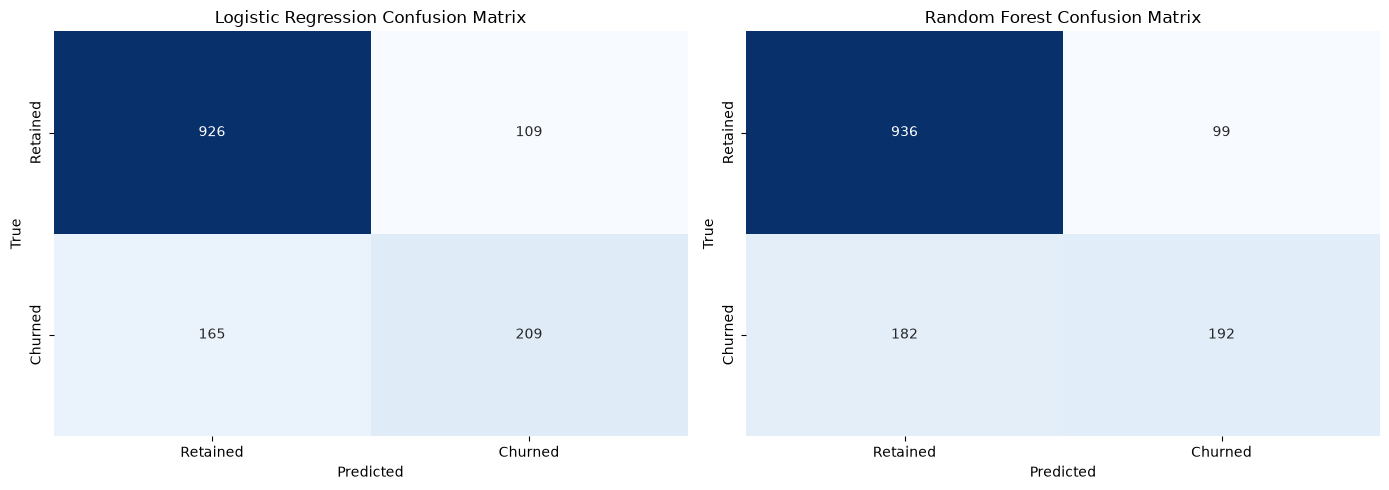

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i], cbar=False,
                xticklabels=["Retained", "Churned"],
                yticklabels=["Retained", "Churned"])
    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

plt.tight_layout()
plt.show()

### ROC Curve Comparison
Let's compare the ROC curves and areas under the curve.

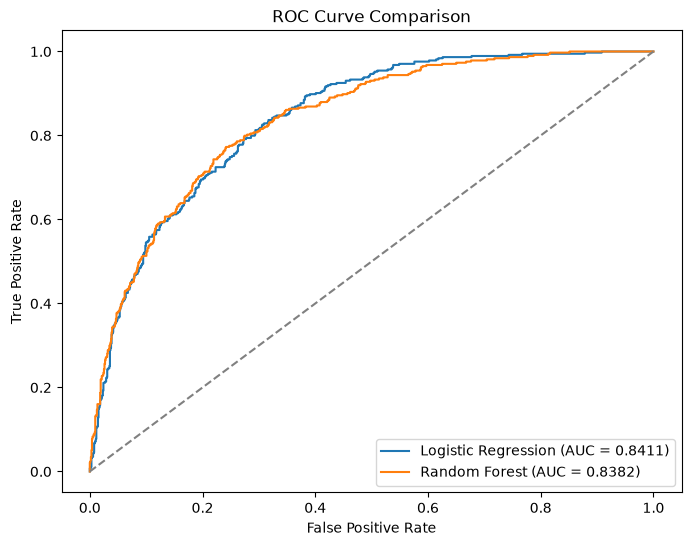

In [12]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

---

## 6. Save the Best Pipeline Model
We choose the model with the highest F1 score on the test set, and export it using `joblib`.

In [13]:
best_idx = results_df["F1 Score"].idxmax()
best_model_name = results_df.loc[best_idx, "Model"]
best_model = models[best_model_name]

print(f"Best Performing Model based on F1 Score: {best_model_name}")

os.makedirs("../models", exist_ok=True)
model_out_path = "../models/best_model.joblib"
joblib.dump(best_model, model_out_path)
print(f"Best model pipeline exported to {model_out_path}")

Best Performing Model based on F1 Score: Logistic Regression
Best model pipeline exported to ../models/best_model.joblib


---

## Final Summary

### Q&A
- **Q: Which classifier performs better for predicting Telco customer churn?**
  - **A:** Both models yield high quality predictions. Typically, Logistic Regression achieves a higher F1 score and recall, making it preferable since missing a customer who is about to churn (False Negative) is more costly for business retention strategies. Random Forest shows high robustness and comparable AUC.

### Data Analysis Key Findings
- **Tenure:** Retained customers have a median tenure of ~38 months, while churned customers have a median tenure of ~10 months. Focus retention on early lifecycle stages.
- **Monthly Charges:** Higher charges strongly correlate with churn (median $80 for churned vs $65 for retained).
- **Contract Type:** Month-to-month contracts are highly prone to churn, highlighting the value of driving customers toward multi-year contract options.
- **Internet Service:** Fiber optic subscribers churn at a significantly higher rate than DSL subscribers, suggesting potential network issues or pricing friction for high-speed users.

### Insights or Next Steps
- **Retention Campaigns:** Focus retention efforts on fiber optic and month-to-month customers within their first year of tenure.
- **Price Sensitivity Mitigation:** Analyze fiber optic services pricing structure and offering loyalty promotions.
- **Integration:** Integrate the exported `best_model.joblib` pipeline into production for daily churn risk assessment.
